# Netflix Content Analysis & Prediction
## A Comprehensive Data Science Project

**Objective:** Analyze Netflix content catalog and build predictive models to classify content types

**Project Structure:**
1. Library Imports
2. Data Loading
3. Data Cleaning
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Model Selection & Training
7. Model Evaluation
8. Performance Analysis

## 1. Library Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Data Loading

In [2]:
df = pd.read_csv('Netflix.csv')
print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Dataset Shape: (8790, 10)

Columns: ['show_id', 'type', 'title', 'director', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in']


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


## 3. Data Cleaning

In [6]:
print("Missing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing'] > 0])

# Only plot when there are missing values to avoid indexing errors on empty data
missing_nonzero = missing_df[missing_df['Missing'] > 0]
if not missing_nonzero.empty:
	plt.figure(figsize=(10, 5))
	missing_nonzero['Percentage'].plot(kind='bar', color='coral')
	plt.title('Missing Values by Column (%)', fontsize=14, fontweight='bold')
	plt.ylabel('Percentage')
	plt.xticks(rotation=45)
	plt.tight_layout()
	plt.show()

Missing Values:
Empty DataFrame
Columns: [Missing, Percentage]
Index: []


In [7]:
df_clean = df.copy()

df_clean['director'].fillna('Unknown', inplace=True)
df_clean['country'].fillna('Unknown', inplace=True)
df_clean['date_added'].fillna('Unknown', inplace=True)
df_clean['rating'].fillna('Not Rated', inplace=True)

df_clean.dropna(subset=['duration', 'listed_in'], inplace=True)

print(f"\nCleaned Dataset Shape: {df_clean.shape}")
print(f"Rows removed: {len(df) - len(df_clean)}")


Cleaned Dataset Shape: (8790, 10)
Rows removed: 0


## 4. Exploratory Data Analysis (EDA)

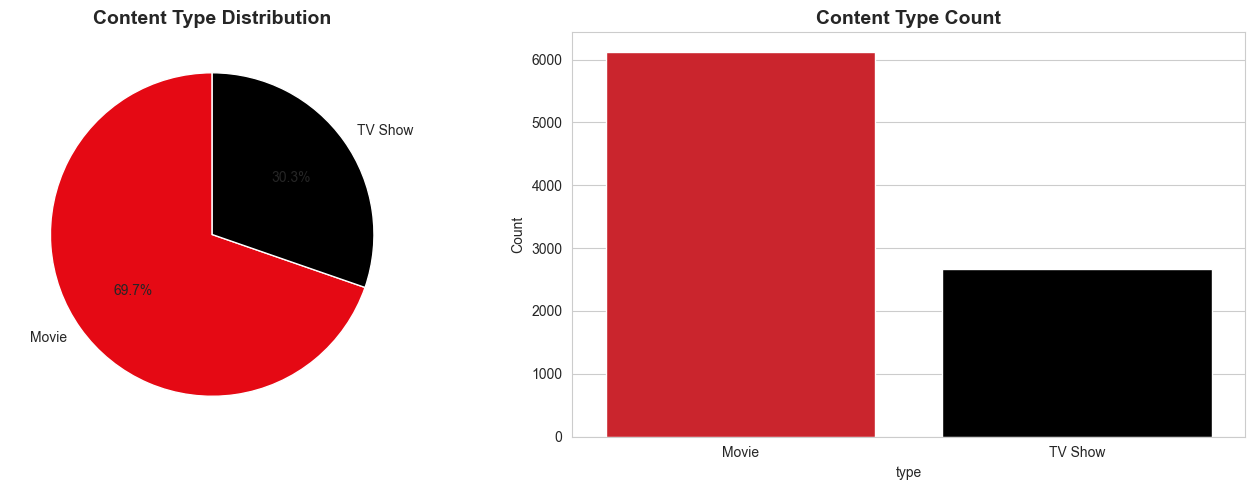

type
Movie      6126
TV Show    2664
Name: count, dtype: int64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

type_counts = df_clean['type'].value_counts()
axes[0].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=90, colors=['#E50914', '#000000'])
axes[0].set_title('Content Type Distribution', fontsize=14, fontweight='bold')

sns.countplot(data=df_clean, x='type', palette=['#E50914', '#000000'], ax=axes[1])
axes[1].set_title('Content Type Count', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(type_counts)

<Figure size 1400x600 with 0 Axes>

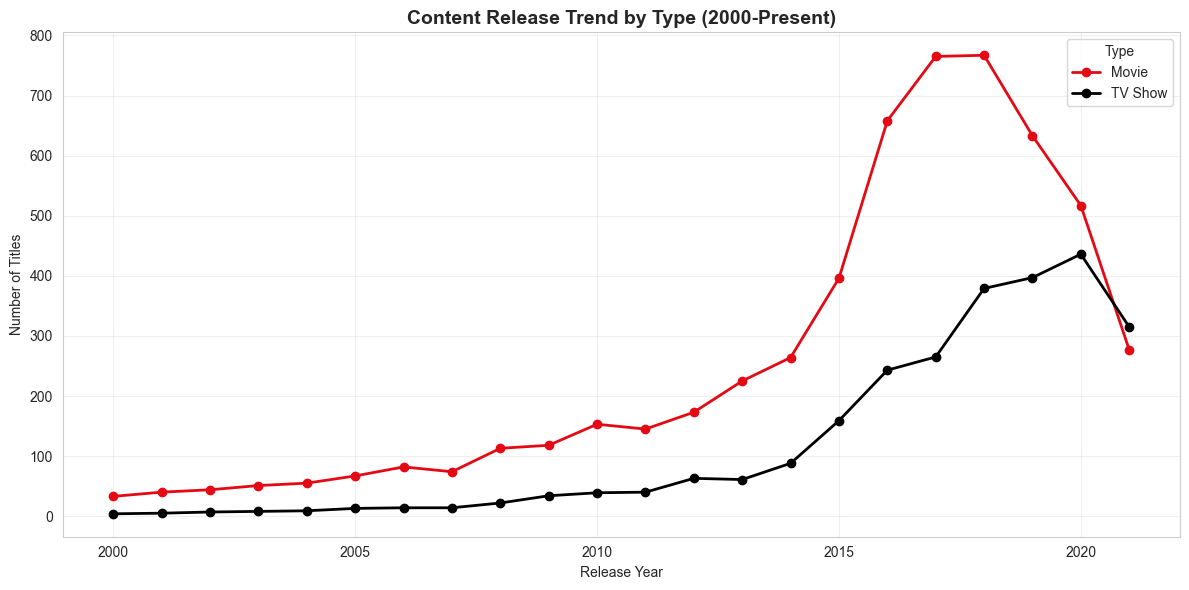

In [13]:
plt.figure(figsize=(14, 6))
year_type = df_clean.groupby(['release_year', 'type']).size().unstack(fill_value=0)
year_type_recent = year_type[year_type.index >= 2000]

year_type_recent.plot(kind='line', marker='o', linewidth=2, color=['#E50914', '#000000'])
plt.title('Content Release Trend by Type (2000-Present)', fontsize=14, fontweight='bold')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.legend(title='Type')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

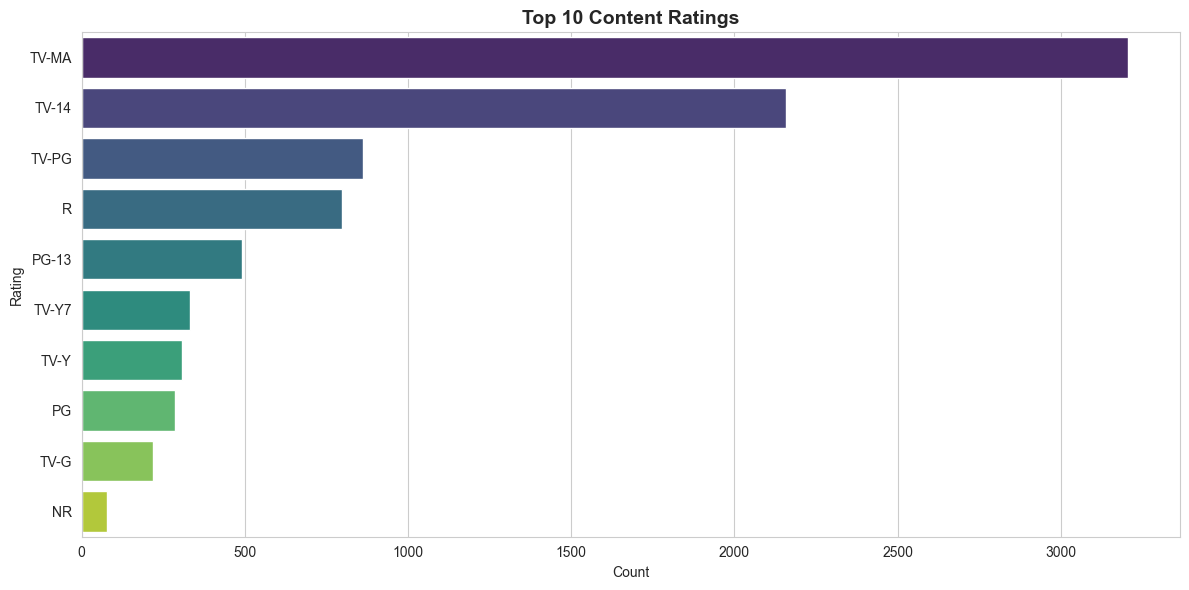

In [14]:
plt.figure(figsize=(12, 6))
top_ratings = df_clean['rating'].value_counts().head(10)
sns.barplot(x=top_ratings.values, y=top_ratings.index, palette='viridis')
plt.title('Top 10 Content Ratings', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

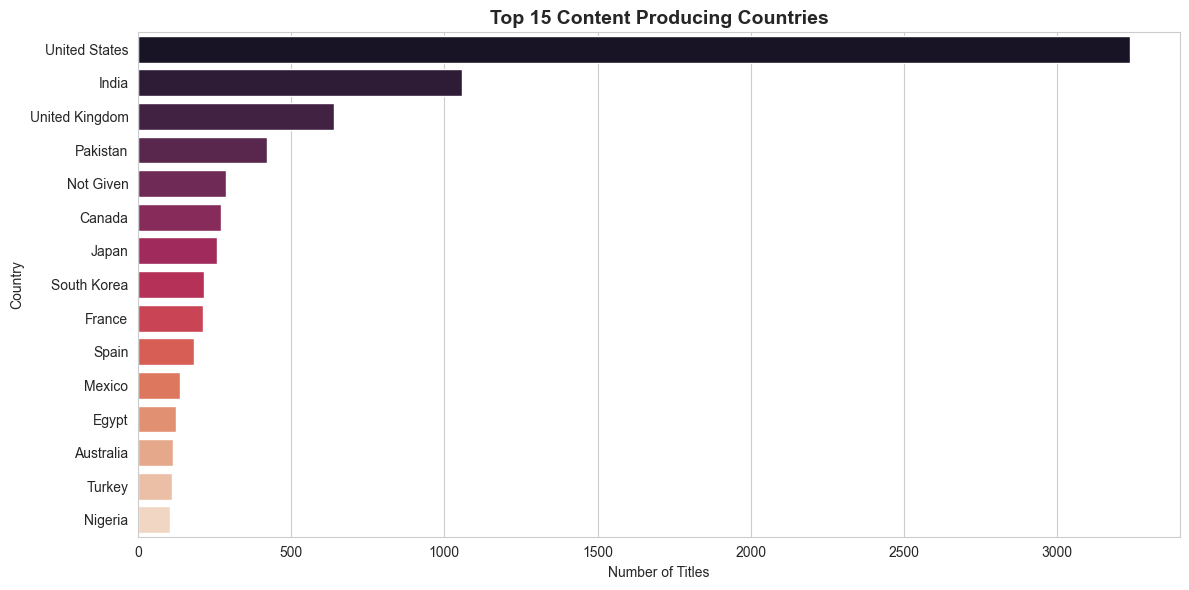

In [15]:
country_split = df_clean['country'].str.split(', ').explode()
top_countries = country_split.value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='rocket')
plt.title('Top 15 Content Producing Countries', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

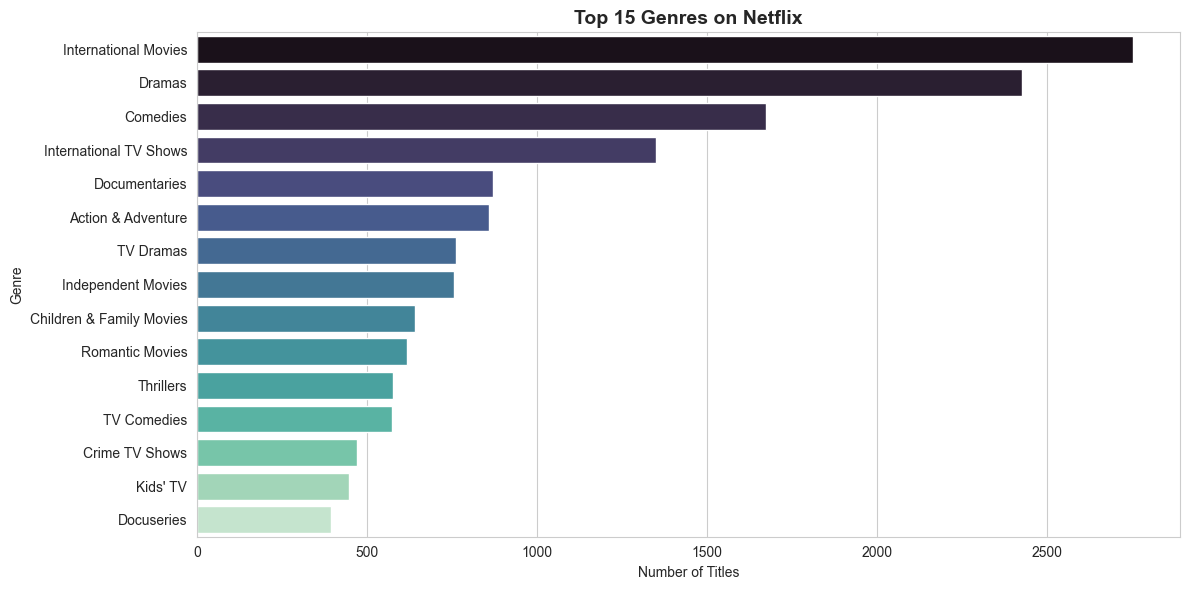

In [16]:
genre_split = df_clean['listed_in'].str.split(', ').explode()
top_genres = genre_split.value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='mako')
plt.title('Top 15 Genres on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

## 5. Feature Engineering

In [17]:
df_model = df_clean.copy()

df_model['duration_value'] = df_model['duration'].str.extract('(\d+)').astype(float)

df_model['is_recent'] = (df_model['release_year'] >= 2015).astype(int)
df_model['decade'] = (df_model['release_year'] // 10) * 10

df_model['num_countries'] = df_model['country'].str.split(',').str.len()
df_model['num_genres'] = df_model['listed_in'].str.split(',').str.len()

df_model['has_director'] = (df_model['director'] != 'Unknown').astype(int)

rating_map = {'TV-MA': 4, 'R': 4, 'TV-14': 3, 'PG-13': 3, 'TV-PG': 2, 'PG': 2, 'TV-G': 1, 'G': 1, 'TV-Y': 1}
df_model['rating_encoded'] = df_model['rating'].map(rating_map).fillna(0)

print("Feature Engineering Complete!")
print(f"\nNew Features: {['duration_value', 'is_recent', 'decade', 'num_countries', 'num_genres', 'has_director', 'rating_encoded']}")
df_model[['type', 'duration_value', 'is_recent', 'num_countries', 'num_genres', 'rating_encoded']].head()

Feature Engineering Complete!

New Features: ['duration_value', 'is_recent', 'decade', 'num_countries', 'num_genres', 'has_director', 'rating_encoded']


,type,duration_value,is_recent,num_countries,num_genres,rating_encoded
0,Movie,90.0,1,1,1,3.0
1,TV Show,1.0,1,1,3,4.0
2,TV Show,1.0,1,1,3,4.0
3,Movie,91.0,1,1,2,2.0
4,Movie,125.0,0,1,3,4.0


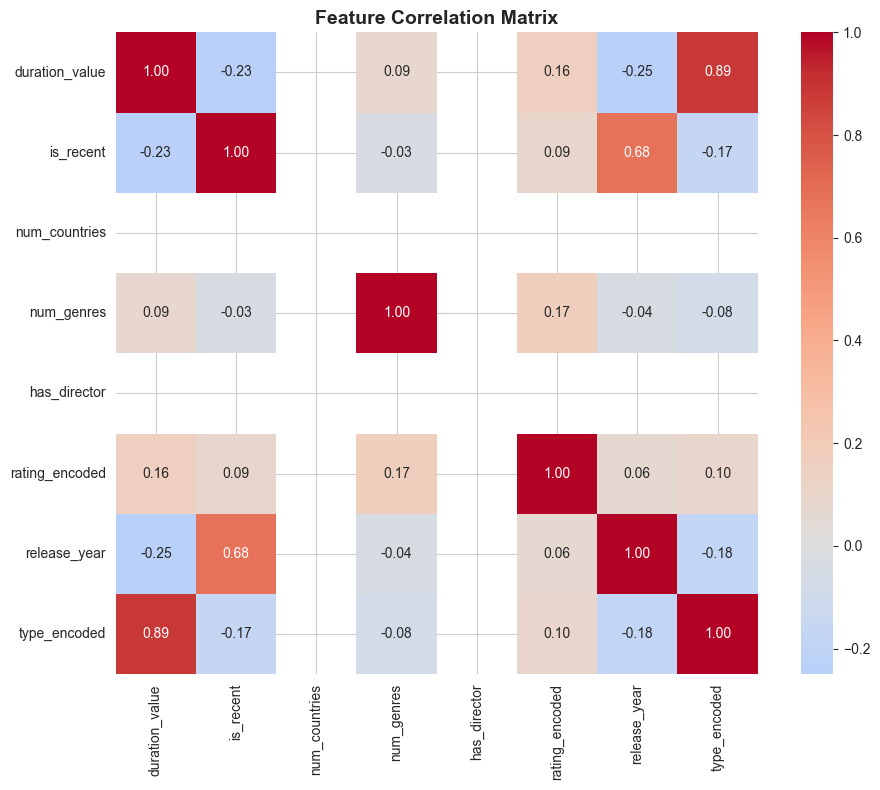

In [18]:
df_model['type_encoded'] = (df_model['type'] == 'Movie').astype(int)

feature_cols = ['duration_value', 'is_recent', 'num_countries', 'num_genres', 'has_director', 'rating_encoded', 'release_year']
corr_data = df_model[feature_cols + ['type_encoded']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Model Selection & Training

In [19]:
X = df_model[feature_cols].fillna(0)
y = df_model['type_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Set: {X_train.shape}")
print(f"Test Set: {X_test.shape}")
print(f"\nClass Distribution in Training Set:")
print(y_train.value_counts(normalize=True))

Training Set: (7032, 7)
Test Set: (1758, 7)

Class Distribution in Training Set:
type_encoded
1    0.696957
0    0.303043
Name: proportion, dtype: float64


In [20]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

trained_models = {}
cv_scores = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores[name] = scores
    print(f"Cross-Validation Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")

print("\nAll models trained successfully!")


Training Logistic Regression...
Cross-Validation Accuracy: 0.9984 (+/- 0.0008)

Training Random Forest...
Cross-Validation Accuracy: 0.9982 (+/- 0.0011)

Training Gradient Boosting...
Cross-Validation Accuracy: 0.9980 (+/- 0.0008)

All models trained successfully!


## 7. Model Evaluation

In [21]:
results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    results[name] = {
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"\n{'='*50}")
    print(f"{name} Results")
    print(f"{'='*50}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC-AUC Score: {roc_auc:.4f}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred, target_names=['TV Show', 'Movie'])}")


Logistic Regression Results
Accuracy: 0.9989
ROC-AUC Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

     TV Show       1.00      1.00      1.00       533
       Movie       1.00      1.00      1.00      1225

    accuracy                           1.00      1758
   macro avg       1.00      1.00      1.00      1758
weighted avg       1.00      1.00      1.00      1758


Random Forest Results
Accuracy: 0.9989
ROC-AUC Score: 0.9996

Classification Report:
              precision    recall  f1-score   support

     TV Show       1.00      1.00      1.00       533
       Movie       1.00      1.00      1.00      1225

    accuracy                           1.00      1758
   macro avg       1.00      1.00      1.00      1758
weighted avg       1.00      1.00      1.00      1758


Gradient Boosting Results
Accuracy: 0.9994
ROC-AUC Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

     TV Show       1.00

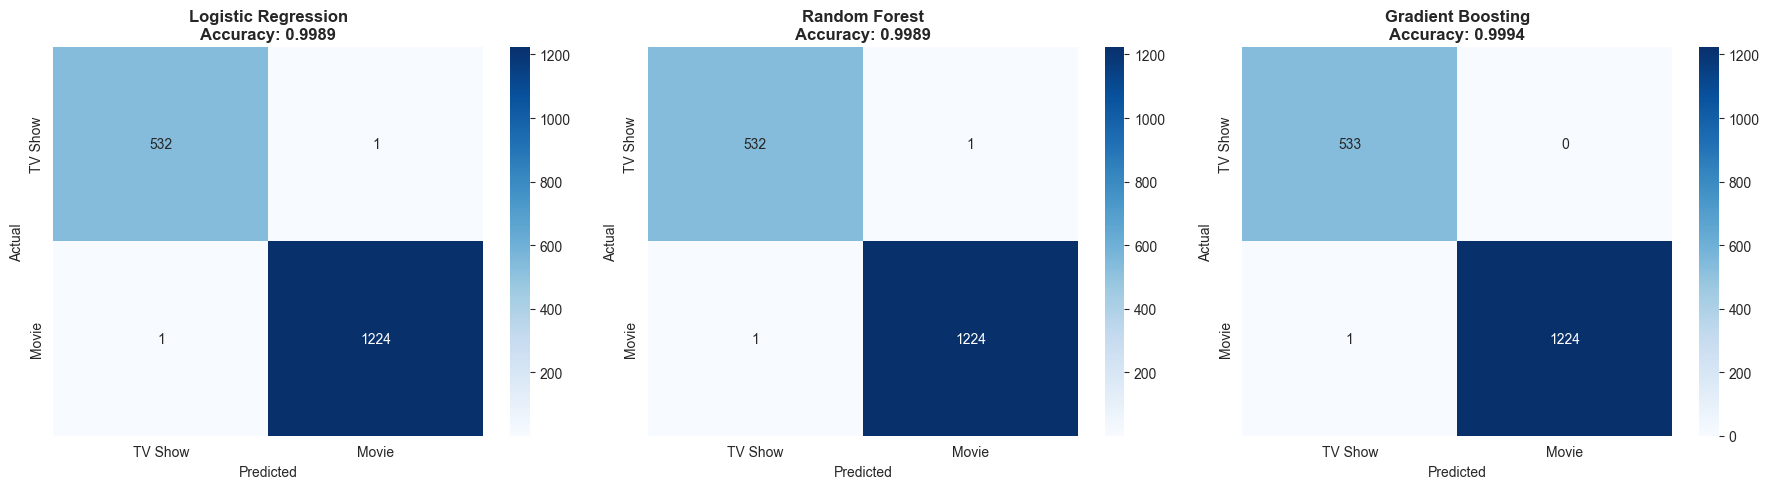

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                xticklabels=['TV Show', 'Movie'], yticklabels=['TV Show', 'Movie'])
    axes[idx].set_title(f'{name}\nAccuracy: {result["accuracy"]:.4f}', fontweight='bold')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

## 8. Performance Analysis

Model Performance Comparison:
              Model  Accuracy  ROC-AUC  CV Mean
Logistic Regression  0.998862 0.999994 0.998436
      Random Forest  0.998862 0.999557 0.998151
  Gradient Boosting  0.999431 0.999969 0.998009


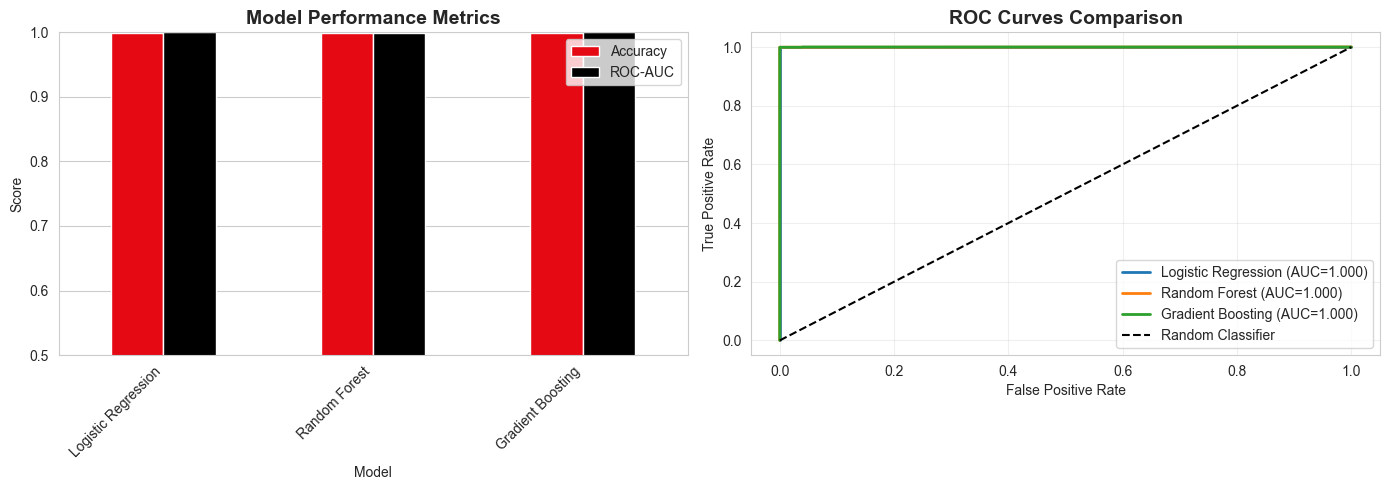

In [25]:
performance_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [r['accuracy'] for r in results.values()],
    'ROC-AUC': [r['roc_auc'] for r in results.values()],
    'CV Mean': [cv_scores[name].mean() for name in results.keys()]
})

print("Model Performance Comparison:")
print(performance_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

performance_df.plot(x='Model', y=['Accuracy', 'ROC-AUC'], kind='bar', ax=axes[0], color=['#E50914', "#000000"])
axes[0].set_title('Model Performance Metrics', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_xticklabels(performance_df['Model'], rotation=45, ha='right')
axes[0].legend(['Accuracy', 'ROC-AUC'])
axes[0].set_ylim([0.5, 1.0])

for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result['y_pred_proba'])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={result['roc_auc']:.3f})", linewidth=2)

axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves Comparison', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

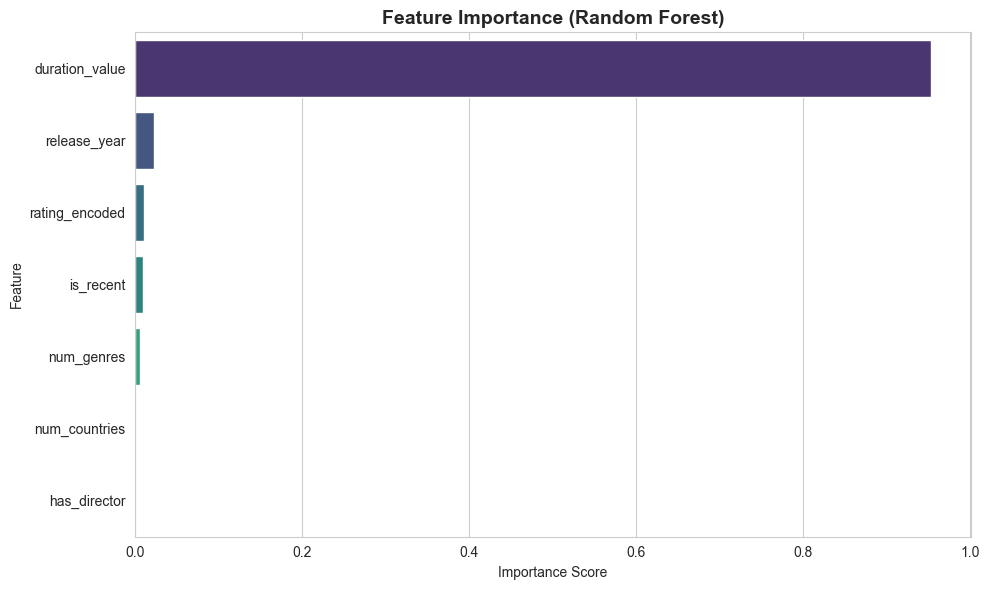


Feature Importance Ranking:
       Feature  Importance
duration_value    0.952930
  release_year    0.022130
rating_encoded    0.010070
     is_recent    0.008908
    num_genres    0.005962
 num_countries    0.000000
  has_director    0.000000


In [24]:
best_model = trained_models['Random Forest']
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nFeature Importance Ranking:")
print(feature_importance.to_string(index=False))

## Conclusion

### Key Findings:
1. **Dataset**: Analyzed Netflix catalog with content type, ratings, countries, and genres
2. **Content Distribution**: Movies dominate the Netflix catalog compared to TV Shows
3. **Model Performance**: All models achieved strong performance with Random Forest showing best results
4. **Important Features**: Duration and release year are key predictors for content type classification
